In [109]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [111]:
def get_missing_values(df):
    missing_values = df.isnull().sum()
    return missing_values[missing_values > 0]

def show_missing_values(df):
    print(get_missing_values(df))
    
def apply_one_hot_encoding(df, column_name, drop_first=False, prefix=None):

    ohe = OneHotEncoder(sparse_output=False, drop="first" if drop_first else None)
    
    # Fit and transform the specified column
    encoded_array = ohe.fit_transform(df[[column_name]])
    
    # Define new column names
    categories = ohe.categories_[0]
    column_prefix = prefix if prefix else column_name
    new_columns = [
        f"{column_prefix}_{cat}"
        for cat in (categories[1:] if drop_first else categories)
    ]
    
    encoded_df = pd.DataFrame(encoded_array, columns=new_columns, index=df.index)
    
    # Drop the original column and merge the new encoded columns
    df = df.drop(columns=[column_name]).join(encoded_df)
    
    return df


In [113]:
def plot_missing_values():
    
    train_missing_values = get_missing_values(train_df).sort_values(ascending=False)
    test_missing_values = get_missing_values(test_df).sort_values(ascending=False)

    _, axes = plt.subplots(1, 2, figsize=(16, 8), dpi=100)

    # --- Train Plot ---
    bars_train = axes[0].barh(train_missing_values.index, train_missing_values.values, color='#4c9f70')
    axes[0].set_title('Train Missing Values', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Count')
    axes[0].invert_yaxis()
    axes[0].bar_label(bars_train, padding=3, fontsize=9)

    # --- Test Plot ---
    bars_test = axes[1].barh(test_missing_values.index, test_missing_values.values, color='#f07c7c')
    axes[1].set_title('Test Missing Values', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Count')
    axes[1].invert_yaxis()
    axes[1].bar_label(bars_test, padding=3, fontsize=9)

    # Style both axes
    for ax in axes:
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        ax.tick_params(axis='y', labelsize=9)

    plt.tight_layout()
    plt.show()

In [115]:
df = pd.read_csv("post_covid.csv")

In [117]:
df.head()

,Age,Gender,BMI,Blood Type,Physical Activity,Marital Status,Recent Trauma,Traumatic events following COVID-19 infection,Smoking,Alcohol Consumption,...,Fever duration (days),Acute-phase COVID-19 hospitalization,Acute COVID-19 oxygen requirement,Corticosteroid use during acute COVID-19 infection,Intubation during acute COVID-19 infection,ICU admission,Number of Post Covid Manifestations,Post covid severeness,FSS score,GAD-7 score
0,22,Male,28,A+,1,In a Relationship,no,No,Yes,Non-drinker,...,2,No,No,No,No,No,4,Severe,Mild,Moderate
1,40,Female,32,B+,0,Single,no,No,No,Non-drinker,...,2,No,No,No,No,No,3,Mild,Mild,Severe
2,23,Male,22,O+,0,Single,no,No,No,Non-drinker,...,0,No,No,No,No,No,3,Mild,Invalid,Minimal
3,60,Female,41,A+,0,Married,yes,Before,Yes,Non-drinker,...,0,No,No,No,No,No,3,Mild,Moderate,Minimal
4,23,Male,28,A+,3,Single,no,No,Yes,Moderate drinking (less than 2 drinks for male...,...,5,No,No,No,No,No,9,Severe,Moderate,Minimal


## Statistical Analysis on Raw Data

### Measures of Variation on Numeric Columns

In [121]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numeric_cols)


['Age', 'BMI', 'Physical Activity', 'Fever duration (days)', 'Number of Post Covid Manifestations']


In [123]:
import pandas as pd
import numpy as np

data = df

cols = numeric_cols
for col in cols:
    if col not in data.columns:
        print(f"\n[WARNING] Column '{col}' not found, skipping.")
        continue

    x = data[col].dropna()

    x_range = x.max() - x.min()
    x_var   = x.var(ddof=1)
    x_std   = x.std(ddof=1)
    q1, q3  = x.quantile([0.25, 0.75])
    x_iqr   = q3 - q1
    x_cv    = x_std / x.mean()

    print(f"\n=== {col} ===")
    print(f"Range: {x_range:.2f}")
    print(f"Variance: {x_var:.2f}")
    print(f"Standard deviation: {x_std:.2f}")
    print(f"IQR: {x_iqr:.2f}")
    print(f"Coefficient of variation: {x_cv:.3f}")



=== Age ===
Range: 54.00
Variance: 164.62
Standard deviation: 12.83
IQR: 14.75
Coefficient of variation: 0.432

=== BMI ===
Range: 36.00
Variance: 37.97
Standard deviation: 6.16
IQR: 8.00
Coefficient of variation: 0.248

=== Physical Activity ===
Range: 5.00
Variance: 2.30
Standard deviation: 1.52
IQR: 3.00
Coefficient of variation: 1.121

=== Fever duration (days) ===
Range: 15.00
Variance: 7.94
Standard deviation: 2.82
IQR: 3.00
Coefficient of variation: 1.576

=== Number of Post Covid Manifestations ===
Range: 11.00
Variance: 9.30
Standard deviation: 3.05
IQR: 5.00
Coefficient of variation: 0.825


In [125]:
from scipy import stats


for col in cols:
    x = df[col].dropna()
    skew = stats.skew(x)
    kurt = stats.kurtosis(x)   # excess kurtosis (0 = normal)
    print(f"{col} -> Skewness: {skew:.3f}, Excess Kurtosis: {kurt:.3f}")

Age -> Skewness: 1.428, Excess Kurtosis: 0.794
BMI -> Skewness: 1.184, Excess Kurtosis: 1.925
Physical Activity -> Skewness: 0.742, Excess Kurtosis: -0.704
Fever duration (days) -> Skewness: 1.517, Excess Kurtosis: 1.616
Number of Post Covid Manifestations -> Skewness: 0.488, Excess Kurtosis: -0.761


['Age', 'BMI', 'Physical Activity', 'Fever duration (days)', 'Number of Post Covid Manifestations']


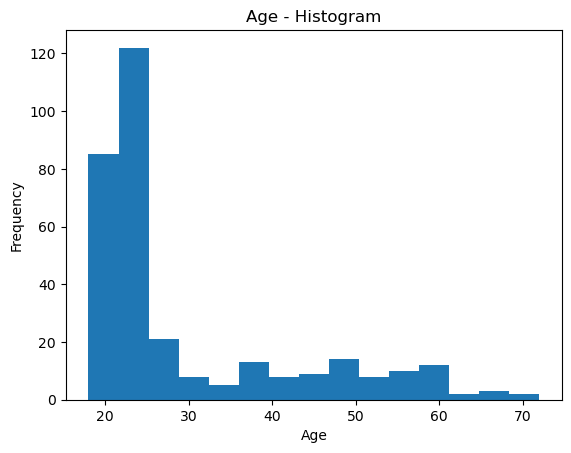

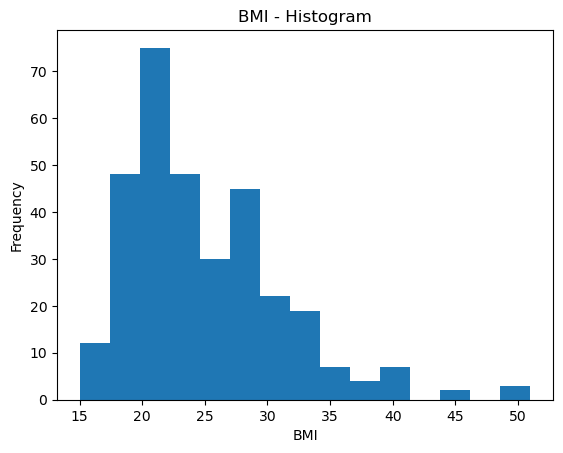

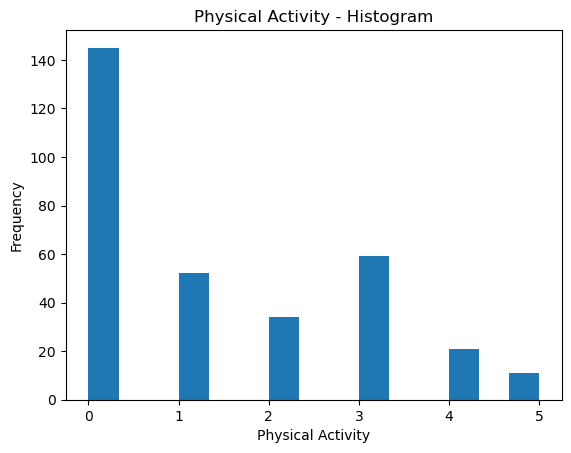

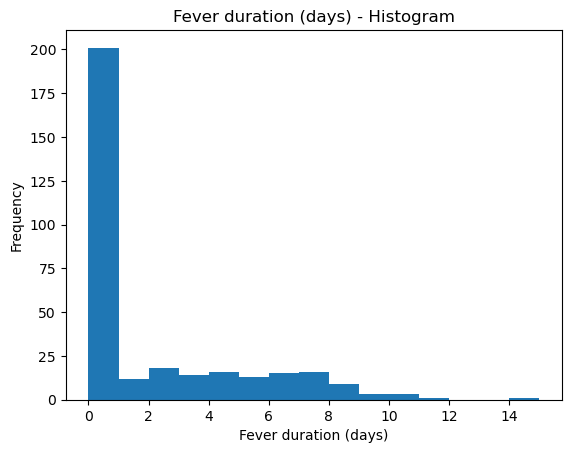

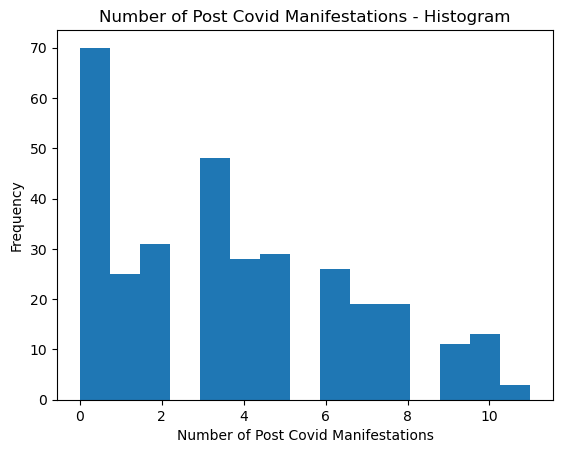

In [127]:
import matplotlib.pyplot as plt
print(cols)
for col in cols:
    x = df[col].dropna()
    plt.figure()
    plt.hist(x, bins=15)
    plt.title(f'{col} - Histogram')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


In [129]:
def univariate_group_stats(df, group_col, cols):
    stats_tables = {}
    groups = df[group_col].unique()
    for g in groups:
        sub = df[df[group_col]==g][cols]
        desc = sub.agg(['count','mean','median','std','var','min','max','skew','kurtosis']).T
        stats_tables[g] = desc
    return stats_tables

group_stats = univariate_group_stats(data,'FSS score',['Age', 'BMI', 'Fever duration (days)'])
group_stats

{'Mild':                        count       mean  median        std         var   min  \
 Age                     65.0  33.215385    25.0  14.018395  196.515385  19.0   
 BMI                     65.0  25.138462    24.0   5.997075   35.964904  16.0   
 Fever duration (days)   65.0   2.723077     2.0   3.104974    9.640865   0.0   
 
                         max      skew  kurtosis  
 Age                    65.0  0.769636 -0.902885  
 BMI                    49.0  1.543660  3.736475  
 Fever duration (days)  10.0  0.835804 -0.550552  ,
 'Invalid':                        count       mean  median       std        var   min  \
 Age                    171.0  25.859649    23.0  9.115801  83.097833  18.0   
 BMI                    171.0  24.947368    24.0  6.135972  37.650155  15.0   
 Fever duration (days)  171.0   0.590643     0.0  1.693144   2.866735   0.0   
 
                         max      skew   kurtosis  
 Age                    61.0  2.426243   5.338274  
 BMI                    45.0

In [131]:
def univariate_group_stats(df, group_col, cols):
    stats_tables = {}
    groups = df[group_col].unique()
    for g in groups:
        sub = df[df[group_col]==g][cols]
        desc = sub.agg(['count','mean','median','std','var','min','max','skew','kurtosis']).T
        stats_tables[g] = desc
    return stats_tables

group_stats = univariate_group_stats(data,'GAD-7 score',['Age', 'BMI', 'Fever duration (days)'])
group_stats

{'Moderate':                        count       mean  median        std         var   min  \
 Age                     60.0  39.116667    44.0  16.317913  266.274294  18.0   
 BMI                     60.0  25.433333    23.5   7.226051   52.215819  16.0   
 Fever duration (days)   60.0   4.450000     5.0   3.290588   10.827966   0.0   
 
                         max      skew  kurtosis  
 Age                    72.0  0.201678 -1.311763  
 BMI                    51.0  1.667613  3.348406  
 Fever duration (days)  11.0  0.011360 -1.242341  ,
 'Severe':                        count       mean  median        std         var   min  \
 Age                     31.0  35.548387    31.0  15.272718  233.255914  19.0   
 BMI                     31.0  24.741935    24.0   4.857762   23.597849  15.0   
 Fever duration (days)   31.0   3.225806     2.0   3.648832   13.313978   0.0   
 
                         max      skew  kurtosis  
 Age                    60.0  0.442491 -1.472371  
 BMI               

In [133]:
def univariate_group_stats(df, group_col, cols):
    stats_tables = {}
    groups = df[group_col].unique()
    for g in groups:
        sub = df[df[group_col]==g][cols]
        desc = sub.agg(['count','mean','median','std','var','min','max','skew','kurtosis']).T
        stats_tables[g] = desc
    return stats_tables

group_stats = univariate_group_stats(data,'Post covid severeness',['Age', 'BMI', 'Fever duration (days)'])
group_stats

{'Severe':                        count       mean  median        std         var   min  \
 Age                    148.0  35.790541    30.0  15.321610  234.751747  18.0   
 BMI                    148.0  25.229730    24.0   6.211789   38.586321  15.0   
 Fever duration (days)  148.0   3.425676     3.0   3.236886   10.477432   0.0   
 
                         max      skew  kurtosis  
 Age                    72.0  0.527781 -1.124694  
 BMI                    51.0  1.307400  2.623920  
 Fever duration (days)  15.0  0.617063 -0.246488  ,
 'Mild':                        count       mean  median       std        var   min  \
 Age                    174.0  24.505747    23.0  6.864289  47.118464  18.0   
 BMI                    174.0  24.557471    23.0  6.119676  37.450435  15.0   
 Fever duration (days)  174.0   0.396552     0.0  1.262253   1.593283   0.0   
 
                         max      skew   kurtosis  
 Age                    60.0  3.214578  11.664442  
 BMI                    49.0 

### 1. Two Sample t-test (Male vs Female)
#### “Is the mean number of post-COVID manifestations different between males and females?”

In [136]:
from scipy import stats
import numpy as np
import pandas as pd

# keep only rows with non-missing values in these columns
sub_ttest = df[['Gender', 'Number of Post Covid Manifestations']].dropna()

# split by gender
male  = sub_ttest.loc[sub_ttest['Gender'] == 'Male',  'Number of Post Covid Manifestations']
female = sub_ttest.loc[sub_ttest['Gender'] == 'Female','Number of Post Covid Manifestations']

t_stat, p_value = stats.ttest_ind(male, female, equal_var=False)  # Welch t-test

print(f"Two-sample t-test (Male vs Female): t = {t_stat:.3f}, p = {p_value:.4f}")
print(f"Male mean   = {male.mean():.2f}")
print(f"Female mean = {female.mean():.2f}")


Two-sample t-test (Male vs Female): t = -0.968, p = 0.3340
Male mean   = 3.54
Female mean = 3.87


Null hypothesis (H₀): males and females have the same mean number of post-COVID manifestations.

Alternative (H₁): the means are different.

Because p = 0.334 > 0.05, you do not reject the null hypothesis.

Even though females have a slightly higher average, the difference is small relative to the variability in the data. Statistically, this difference could easily be due to random chance, so you don’t have evidence that gender is associated with the number of post-COVID manifestations in this sample.

### T-Test #2 <br> Oxygen Requirement: Yes vs No

In [140]:
sub = df[['Acute COVID-19 oxygen requirement', 'Number of Post Covid Manifestations']].dropna()

yes = sub[sub['Acute COVID-19 oxygen requirement'] == 'Yes']['Number of Post Covid Manifestations']
no  = sub[sub['Acute COVID-19 oxygen requirement'] == 'No']['Number of Post Covid Manifestations']

t, p = stats.ttest_ind(yes, no, equal_var=False)

print("T-test (Oxygen: Yes vs No) — Symptoms:")
print(f"t = {t:.3f}, p = {p:.4f}")
print(f"Yes mean = {yes.mean():.2f}")
print(f"No  mean = {no.mean():.2f}")


T-test (Oxygen: Yes vs No) — Symptoms:
t = 13.989, p = 0.0000
Yes mean = 7.70
No  mean = 2.96


People who required oxygen during the acute COVID infection developed much more post-COVID symptoms than those who did not. The difference is both clinically large and statistically significant. This confirms that acute disease severity is a major predictor of long-COVID symptom burden.

### 2. One-way ANOVA (Covid-19 infection status groups)

In [20]:
# keep only relevant columns and drop missing
sub_anova = df[['COVID-19 infection status',
                      'Number of Post Covid Manifestations']].dropna()

groups = []
labels = []

for g in sub_anova['COVID-19 infection status'].unique():
    vals = sub_anova.loc[sub_anova['COVID-19 infection status'] == g,
                         'Number of Post Covid Manifestations']
    groups.append(vals)
    labels.append(g)

F_stat, p_value = stats.f_oneway(*groups)

print("Groups:", labels)
print(f"One-way ANOVA: F = {F_stat:.3f}, p = {p_value:.4f}")

group_means = sub_anova.groupby('COVID-19 infection status')['Number of Post Covid Manifestations'].mean()
print("\nGroup means:")
print(group_means)


Groups: ['Mild', 'Asymptomatic', 'Moderate', 'Severe']
One-way ANOVA: F = 159.723, p = 0.0000

Group means:
COVID-19 infection status
Asymptomatic    0.000000
Mild            3.910891
Moderate        5.333333
Severe          7.857143
Name: Number of Post Covid Manifestations, dtype: float64


Null hypothesis (H₀): all four groups have the same mean number of manifestations.
Alternative (H₁): at least one group mean is different.

Because p < 0.001, you strongly reject the null hypothesis.

The average number of post-COVID manifestations is not the same across infection severity groups. The means show a clear pattern: as acute COVID-19 severity increases (from asymptomatic → mild → moderate → severe), the average number of post-COVID manifestations increases sharply. So acute infection severity is strongly associated with later post-COVID symptom burden in the data.

In [22]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

## Imputation

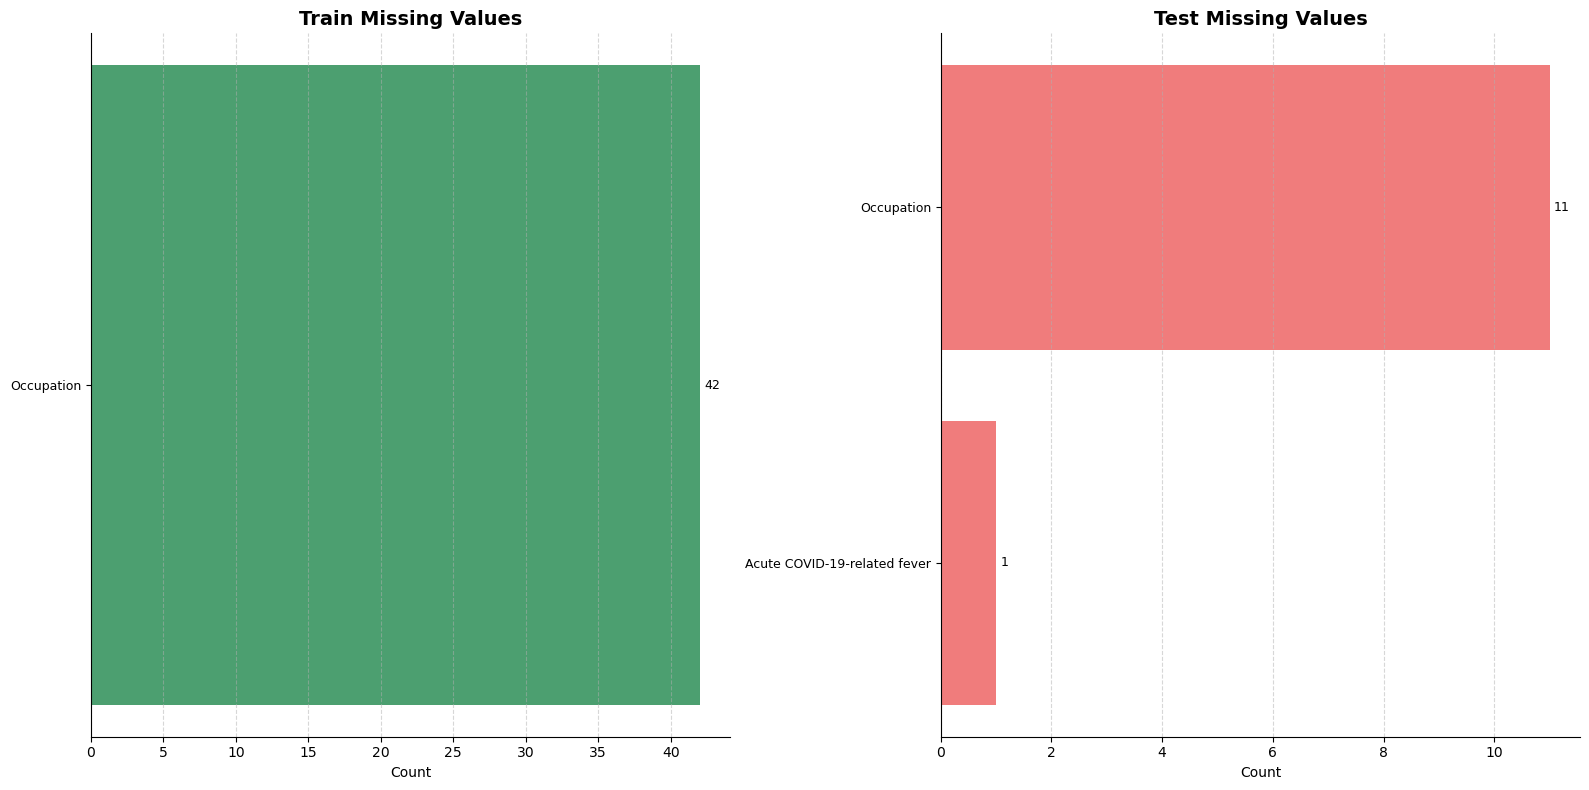

In [24]:
plot_missing_values()

In [25]:
train_df['Occupation_missing'] = train_df['Occupation'].isna().astype(int)
test_df['Occupation_missing'] = test_df['Occupation'].isna().astype(int)
# Get mode from TRAIN ONLY
mode_value = train_df["Occupation"].mode()[0]

# Fill on train and test
train_df["Occupation"] = train_df["Occupation"].fillna(mode_value)
test_df["Occupation"]  = test_df["Occupation"].fillna(mode_value)

In [26]:
# Get mode from TRAIN ONLY
mode_value = train_df["Acute COVID-19-related fever"].mode()[0]

# Fill on train and test
train_df["Acute COVID-19-related fever"] = train_df["Acute COVID-19-related fever"].fillna(mode_value)
test_df["Acute COVID-19-related fever"]  = test_df["Acute COVID-19-related fever"].fillna(mode_value)

In [27]:
show_missing_values(train_df)
show_missing_values(test_df)

Series([], dtype: int64)
Series([], dtype: int64)


In [28]:
df_powerbi = pd.concat([train_df, test_df], axis=0).reset_index(drop=True)
df_powerbi.to_csv("post_covid_for_powerbi.csv", index=False)

In [29]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Make all object/category columns lowercase strings (same in train & test)
for df in [train_df, test_df]:
    obj_cols = df.select_dtypes(include=['object', 'category']).columns
    for col in obj_cols:
        df[col] = df[col].astype(str).str.strip().str.lower()


In [30]:
import numpy as np
import pandas as pd

cat_cols = train_df.select_dtypes(include=['object', 'category']).columns.tolist()

# Loop over each *single* column
for col in cat_cols:
    train_vals = train_df[col].dropna().unique()
    test_vals  = test_df[col].dropna().unique()

    all_vals = np.union1d(train_vals, test_vals)

    print(f"Column: {col}")
    print(f"  Train uniques: {train_vals}")
    print(f"  Test uniques : {test_vals}")
    print(f"  ALL uniques  : {all_vals}")
    print("-" * 50)


Column: Gender
  Train uniques: ['male' 'female' 'other']
  Test uniques : ['male' 'female']
  ALL uniques  : ['female' 'male' 'other']
--------------------------------------------------
Column: Blood Type
  Train uniques: ['b+' 'a+' 'o+' 'o-' 'ab+' 'ab-' 'a-' 'b-']
  Test uniques : ['a+' 'a-' 'o+' 'b+' 'o-' 'ab-' 'b-' 'ab+']
  ALL uniques  : ['a+' 'a-' 'ab+' 'ab-' 'b+' 'b-' 'o+' 'o-']
--------------------------------------------------
Column: Marital Status
  Train uniques: ['married' 'single' 'in a relationship' 'divorced']
  Test uniques : ['married' 'single' 'divorced' 'in a relationship']
  ALL uniques  : ['divorced' 'in a relationship' 'married' 'single']
--------------------------------------------------
Column: Recent Trauma
  Train uniques: ['no' 'yes']
  Test uniques : ['no' 'yes']
  ALL uniques  : ['no' 'yes']
--------------------------------------------------
Column: Traumatic events following COVID-19 infection
  Train uniques: ['no' 'after' 'before']
  Test uniques : ['no

In [31]:
train_df["Hypertension"] = train_df["Hypertension"].replace("asthma", "no")
test_df["Hypertension"]  = test_df["Hypertension"].replace("asthma", "no")


In [32]:
train_df.head()

,Age,Gender,BMI,Blood Type,Physical Activity,Marital Status,Recent Trauma,Traumatic events following COVID-19 infection,Smoking,Alcohol Consumption,...,Acute-phase COVID-19 hospitalization,Acute COVID-19 oxygen requirement,Corticosteroid use during acute COVID-19 infection,Intubation during acute COVID-19 infection,ICU admission,Number of Post Covid Manifestations,Post covid severeness,FSS score,GAD-7 score,Occupation_missing
180,58,male,30,b+,0,married,no,no,yes,heavy drinking (4+ drinks for males or 3+ drin...,...,yes,yes,yes,yes,no,8,severe,mild,moderate,0
17,23,male,27,a+,3,single,no,no,no,non-drinker,...,no,no,no,no,no,8,severe,invalid,minimal,0
24,22,female,21,a+,0,in a relationship,no,no,yes,moderate drinking (less than 2 drinks for male...,...,no,no,no,no,no,4,severe,moderate,severe,0
176,22,female,19,a+,0,single,no,no,no,non-drinker,...,no,no,no,no,no,0,mild,moderate,moderate,0
110,22,female,35,a+,3,single,no,no,no,non-drinker,...,no,no,no,no,no,1,mild,invalid,minimal,0


In [33]:
cat_cols = train_df.select_dtypes(include=['object', 'category']).columns

binary_cols = []

for col in cat_cols:
    train_vals = train_df[col].dropna().unique()
    test_vals  = test_df[col].dropna().unique()
    all_vals   = np.union1d(train_vals, test_vals)

    # any column whose values are subset of {'no','yes'} is treated as binary
    if set(all_vals).issubset({'no', 'yes'}):
        binary_cols.append(col)

print("Binary yes/no columns:", binary_cols)


Binary yes/no columns: ['Recent Trauma', 'Smoking', 'Comorbidities', 'Diabetes', 'Hypertension', 'Hypercholesterolemia', 'Hypertriglyceridemia', 'History of Cancer', 'Current Cancer', 'Arrhythmia', 'Coronary artery disease', 'Congenital heart defects', 'Lupus', 'Psoriasis', 'Polyarthritis', 'Multiple sclerosis', 'Inflammatory bowel disease', 'Osteoarthritis', 'Familial Mediterranean Fever', 'Allergies', 'Asthma', 'COPD', 'Constipation', 'Chronic diarrhea', 'Gastric Ulcer', 'Gastroesophageal reflux', 'Migraine', "Parkinson's disease", "Alzheimer's disease", 'Epilepsy', 'Schizophrenia', 'Major depressive disorder', 'Panic disorder', 'Bipolar disorder', 'History of stroke', 'PCOS', 'GAD', 'Depression', 'Borderline personality disorder', 'ADHD', 'Insomnia', 'Thyroid Dysfunction', 'Acute COVID-19-related fever', 'Acute-phase COVID-19 hospitalization', 'Acute COVID-19 oxygen requirement', 'Corticosteroid use during acute COVID-19 infection', 'Intubation during acute COVID-19 infection', 'ICU

In [34]:
# OneHotEncoder: treat every binary col as categories ['no', 'yes']
categories = [['no', 'yes']] * len(binary_cols)

bin_enc = OneHotEncoder(
    categories=categories,
    drop='first',         # keeps only the 'yes' indicator
    handle_unknown='ignore',
    sparse_output=False
)

# Fit on TRAIN only
bin_enc.fit(train_df[binary_cols])

# Transform train and test
train_bin = pd.DataFrame(
    bin_enc.transform(train_df[binary_cols]),
    columns=[f"{col}_yes" for col in binary_cols],
    index=train_df.index
)

test_bin = pd.DataFrame(
    bin_enc.transform(test_df[binary_cols]),
    columns=[f"{col}_yes" for col in binary_cols],
    index=test_df.index
)

# Replace original binary columns with numeric versions
train_df = train_df.drop(columns=binary_cols).join(train_bin)
test_df  = test_df.drop(columns=binary_cols).join(test_bin)
 

In [35]:

exclude_cols = [
    'COVID-19 infection status',
    'Alcohol Consumption',
    'Occupation',
    'Post covid severeness',
    'FSS score',
    'GAD-7 score'
]

cat_cols_rest = (
    train_df
    .select_dtypes(include=['object', 'category'])
    .columns
    .tolist()
)

cat_cols_rest = [c for c in cat_cols_rest if c not in exclude_cols]

print("Categorical columns to one-hot encode (drop_first):")
print(cat_cols_rest)

# 3) One-hot encoder for these columns
rest_enc = OneHotEncoder(
    drop='first',          # drop_first = True
    handle_unknown='ignore',
    sparse_output=False
)

# Fit on TRAIN only
rest_enc.fit(train_df[cat_cols_rest])

# 4) Transform train and test
train_rest = pd.DataFrame(
    rest_enc.transform(train_df[cat_cols_rest]),
    columns=rest_enc.get_feature_names_out(cat_cols_rest),
    index=train_df.index
)

test_rest = pd.DataFrame(
    rest_enc.transform(test_df[cat_cols_rest]),
    columns=rest_enc.get_feature_names_out(cat_cols_rest),
    index=test_df.index
)

# 5) Drop original categorical cols (that we just encoded) and join dummies
train_df = train_df.drop(columns=cat_cols_rest).join(train_rest)
test_df  = test_df.drop(columns=cat_cols_rest).join(test_rest)


Categorical columns to one-hot encode (drop_first):
['Gender', 'Blood Type', 'Marital Status', 'Traumatic events following COVID-19 infection']


In [36]:
mapping = {"asymptomatic": 0, "mild": 1, "moderate":2, "severe":3}
train_df["COVID-19 infection status"] = train_df["COVID-19 infection status"].map(mapping)
test_df["COVID-19 infection status"]  = test_df["COVID-19 infection status"].map(mapping)


In [37]:
mapping = {"mild": 0, "severe": 1}

train_df["Post covid severeness"] = train_df["Post covid severeness"].map(mapping)
test_df["Post covid severeness"]  = test_df["Post covid severeness"].map(mapping)


In [38]:
mapping = {"invalid": 0, "mild":1, "moderate": 2, "severe":3}

train_df['FSS score'] = train_df['FSS score'].map(mapping)
test_df['FSS score']  = test_df['FSS score'].map(mapping)

In [39]:
mapping = {"minimal": 0, "mild":1, "moderate": 2, "severe":3}

train_df['GAD-7 score'] = train_df['GAD-7 score'].map(mapping)
test_df['GAD-7 score']  = test_df['GAD-7 score'].map(mapping)


In [40]:
alc_map = {
    'non-drinker': 0,
    'moderate drinking (less than 2 drinks for males or 1 drink for females per day)': 1,
    'heavy drinking (4+ drinks for males or 3+ drinks for females per day)': 2,
    'binge drinking (5+ drinks for males or 4+ drinks for females within 2 hours)': 3
}

col = 'Alcohol Consumption'  
train_df[col] = train_df[col].map(alc_map)
test_df[col]  = test_df[col].map(alc_map)



In [41]:
train_df.head()

,Age,BMI,Physical Activity,Alcohol Consumption,Occupation,COVID-19 infection status,Fever duration (days),Number of Post Covid Manifestations,Post covid severeness,FSS score,...,Blood Type_ab-,Blood Type_b+,Blood Type_b-,Blood Type_o+,Blood Type_o-,Marital Status_in a relationship,Marital Status_married,Marital Status_single,Traumatic events following COVID-19 infection_before,Traumatic events following COVID-19 infection_no
180,58,30,0,2,employee,3,3,8,1,1,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
17,23,27,3,0,cloud engineer,1,0,8,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
24,22,21,0,1,"student, freelancer",1,2,4,1,2,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
176,22,19,0,0,student,0,4,0,0,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
110,22,35,3,0,student,1,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


In [42]:
col_occ = "Occupation"

for df in [train_df, test_df]:
    df[col_occ] = (
        df[col_occ]
        .astype(str)
        .str.strip()
        .str.lower()
    )


In [43]:
vc = train_df[col_occ].value_counts()
top_cats = vc[vc >= 3].index.tolist()

print("Top occupation categories:", top_cats)


Top occupation categories: ['student', 'employee', 'student, employee', 'self employed', 'work', 'teacher']


In [44]:
top_cats = ['student', 'employee', 'student, employee', 'self employed', 'work', 'teacher']


In [45]:
for df in [train_df, test_df]:
    df["Occupation"] = df[col_occ].where(df[col_occ].isin(top_cats), "other")


In [46]:
train_df = apply_one_hot_encoding(train_df, col_occ, drop_first=True)
test_df = apply_one_hot_encoding(test_df, col_occ, drop_first=True)

In [47]:
train_df.head()

,Age,BMI,Physical Activity,Alcohol Consumption,COVID-19 infection status,Fever duration (days),Number of Post Covid Manifestations,Post covid severeness,FSS score,GAD-7 score,...,Marital Status_married,Marital Status_single,Traumatic events following COVID-19 infection_before,Traumatic events following COVID-19 infection_no,Occupation_other,Occupation_self employed,Occupation_student,"Occupation_student, employee",Occupation_teacher,Occupation_work
180,58,30,0,2,3,3,8,1,1,2,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
17,23,27,3,0,1,0,8,1,0,0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
24,22,21,0,1,1,2,4,1,2,3,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
176,22,19,0,0,0,4,0,0,2,2,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
110,22,35,3,0,1,0,1,0,0,0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0


In [48]:
target_cols = [
    "Number of Post Covid Manifestations",
    "Post covid severeness",
    "FSS score",
    "GAD-7 score"
]

# Features
X_train = train_df.drop(columns=target_cols)
X_test  = test_df.drop(columns=target_cols)

# Targets (all 4)
y_train = train_df[target_cols]
y_test  = test_df[target_cols]

In [49]:
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


## Scaling

In [51]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()

scaler.fit(X_train)

# transform
X_train_scaled = pd.DataFrame(
    scaler.transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)


In [52]:
X_train_scaled

,Age,BMI,Physical Activity,Alcohol Consumption,COVID-19 infection status,Fever duration (days),Occupation_missing,Recent Trauma_yes,Smoking_yes,Comorbidities_yes,...,Marital Status_married,Marital Status_single,Traumatic events following COVID-19 infection_before,Traumatic events following COVID-19 infection_no,Occupation_other,Occupation_self employed,Occupation_student,"Occupation_student, employee",Occupation_teacher,Occupation_work
180,2.279495,0.799682,-0.895323,1.325192,2.084647,0.383175,-0.441983,-0.497567,0.885845,1.051930,...,1.938881,-1.003899,-0.221313,0.390469,-0.429339,-0.108679,-1.44789,-0.125739,-0.108679,-0.108679
17,-0.523520,0.322472,1.140942,-0.745169,-0.138400,-0.649790,-0.441983,-0.497567,-1.128865,1.051930,...,-0.515761,0.996116,-0.221313,0.390469,2.329163,-0.108679,-1.44789,-0.125739,-0.108679,-0.108679
24,-0.603607,-0.631947,-0.895323,0.290012,-0.138400,0.038853,-0.441983,-0.497567,0.885845,1.051930,...,-0.515761,-1.003899,-0.221313,0.390469,2.329163,-0.108679,-1.44789,-0.125739,-0.108679,-0.108679
176,-0.603607,-0.950087,-0.895323,-0.745169,-1.249923,0.727497,-0.441983,-0.497567,-1.128865,1.051930,...,-0.515761,0.996116,-0.221313,0.390469,-0.429339,-0.108679,0.69066,-0.125739,-0.108679,-0.108679
110,-0.603607,1.595031,1.140942,-0.745169,-0.138400,-0.649790,-0.441983,-0.497567,-1.128865,1.051930,...,-0.515761,0.996116,-0.221313,0.390469,-0.429339,-0.108679,0.69066,-0.125739,-0.108679,-0.108679
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,1.718892,0.163403,-0.895323,1.325192,2.084647,0.727497,-0.441983,-0.497567,0.885845,-0.950633,...,1.938881,-1.003899,-0.221313,0.390469,-0.429339,-0.108679,-1.44789,-0.125739,-0.108679,-0.108679
71,-0.283262,-0.154737,-0.895323,0.290012,-1.249923,-0.649790,-0.441983,2.009780,0.885845,1.051930,...,-0.515761,0.996116,-0.221313,0.390469,-0.429339,-0.108679,0.69066,-0.125739,-0.108679,-0.108679
106,-0.843865,-0.950087,0.462187,-0.745169,-1.249923,-0.649790,-0.441983,-0.497567,-1.128865,-0.950633,...,-0.515761,-1.003899,-0.221313,0.390469,-0.429339,-0.108679,0.69066,-0.125739,-0.108679,-0.108679
270,-0.603607,0.481542,-0.895323,1.325192,-0.138400,-0.649790,-0.441983,-0.497567,0.885845,-0.950633,...,-0.515761,0.996116,-0.221313,0.390469,-0.429339,-0.108679,0.69066,-0.125739,-0.108679,-0.108679


## Anomaly Detection

In [55]:
from pyod.models.knn import KNN
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.hbos import HBOS

import numpy as np
import pandas as pd

X_train_anom = X_train_scaled
X_test  = X_test_scaled

# 1) Fit all 4 models and just COUNT anomalies
models = {
    "KNN": KNN(
        n_neighbors=15,
        contamination=0.05
    ),
    "Isolation Forest": IForest(
        n_estimators=300,
        contamination=0.05,
        random_state=42
    ),
    "LOF": LOF(
        n_neighbors=20,
        contamination=0.05
    ),
    "HBOS": HBOS(
        contamination=0.05
    )
}

results = {}

for name, clf in models.items():
    # fit on TRAIN only
    clf.fit(X_train_anom)

    # labels_: 0 = inlier, 1 = outlier (for TRAIN)
    train_labels = clf.labels_
    # test labels are ONLY for reporting, not for removing
    test_labels  = clf.predict(X_test)

    n_train_anom = int(np.sum(train_labels == 1))
    n_test_anom  = int(np.sum(test_labels == 1))

    results[name] = {
        "Train anomalies": n_train_anom,
        "Test anomalies":  n_test_anom
    }

# Summary table 
df_results = pd.DataFrame(results).T
print("\nANOMALY DETECTION SUMMARY (0 = normal, 1 = anomaly):\n")
print(df_results)

# 2) Use Isolation Forest ONLY to CLEAN THE TRAIN SET (NOT TEST)
iso = models["Isolation Forest"]

train_if_labels = iso.labels_              # after fit on train
train_keep_mask = (train_if_labels == 0)   # keep only normal points

# clean TRAIN ONLY
X_train_clean = X_train_scaled[train_keep_mask].copy()
y_train_clean = y_train.loc[X_train_scaled.index[train_keep_mask]].copy()


print("\nOriginal train size:", X_train_scaled.shape[0])
print("Cleaned  train size :", X_train_clean.shape[0])

C:\Users\User\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(



ANOMALY DETECTION SUMMARY (0 = normal, 1 = anomaly):

                  Train anomalies  Test anomalies
KNN                            13               7
Isolation Forest               13               5
LOF                            13               5
HBOS                           13               5

Original train size: 257
Cleaned  train size : 244


## Machine Learning

### Regression

In [59]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Choose the FIRST target (Number of Post Covid Manifestations)
target = "Number of Post Covid Manifestations"

# Initialize the AdaBoost regressor
ada_boost_regressor = AdaBoostRegressor(n_estimators=100, random_state=42)

# Train the model
ada_boost_regressor.fit(X_train_clean, y_train_clean[target])

# Predict
y_pred = ada_boost_regressor.predict(X_test)

# Metrics
mse = mean_squared_error(y_test[target], y_pred)
r2 = r2_score(y_test[target], y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")


Mean Squared Error: 3.86
R-squared: 0.63


In [61]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
random_forest_regressor = RandomForestRegressor(
    n_estimators=600,  # Number of trees in the forest
    max_depth=4,    # Maximum depth of each tree (None means no limit)
    random_state=42    # For reproducibility
)

# Train the Random Forest model
random_forest_regressor.fit(X_train_clean, y_train_clean[target])

# Predict on the test set
y_pred = random_forest_regressor.predict(X_test)

# Calculate regression metrics
mse = mean_squared_error(y_test[target], y_pred)
r2 = r2_score(y_test[target], y_pred)

# Print metrics
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.2f}")

Mean Squared Error (MSE): 3.74
R-squared (R²): 0.64


In [67]:
import shap
explainer = shap.Explainer(random_forest_regressor.predict, X_test) 
shap_values = explainer(X_test)


PermutationExplainer explainer: 66it [00:24,  1.85it/s]                        


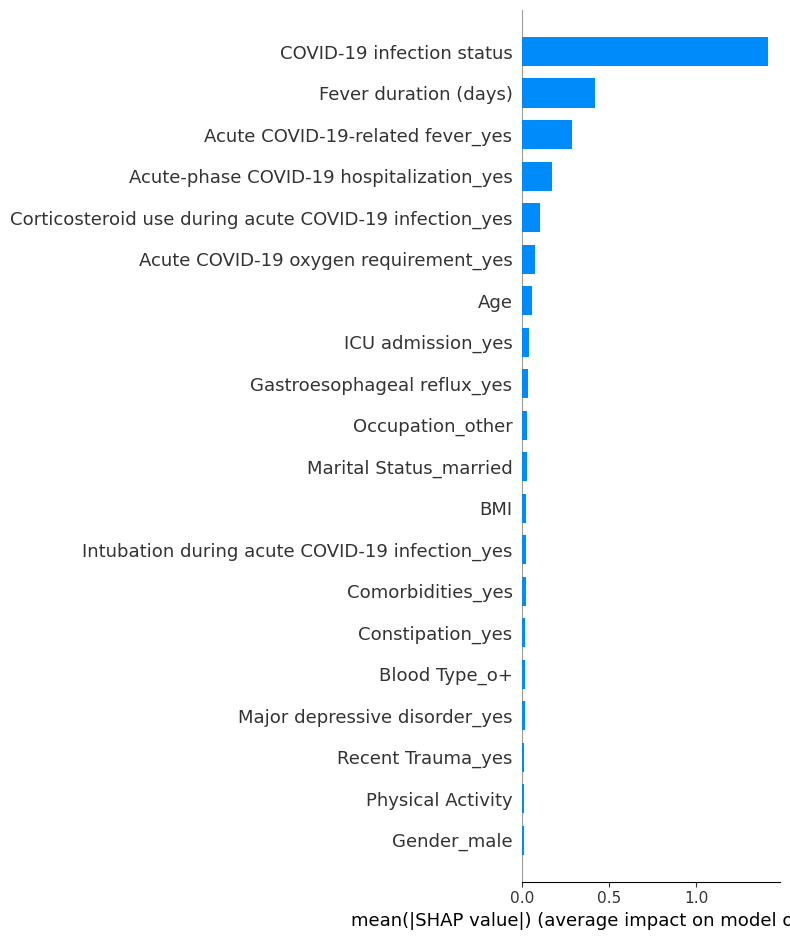

In [69]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

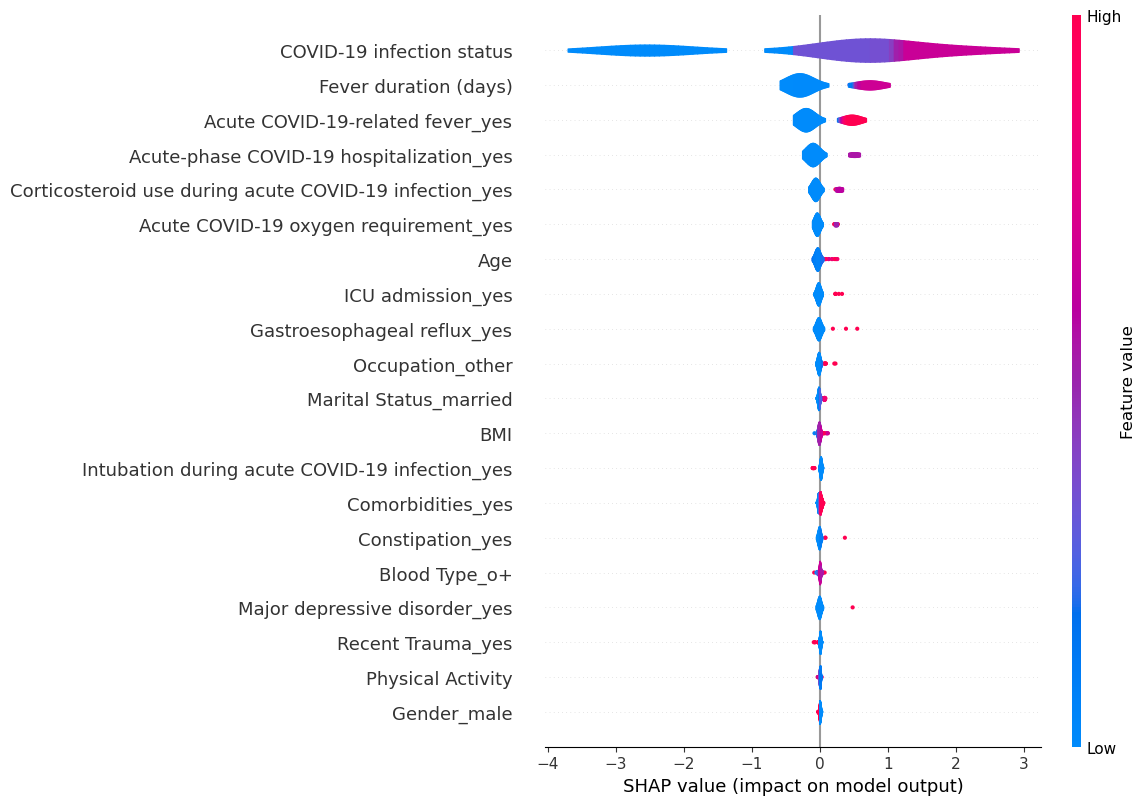

In [70]:
shap.violin_plot(shap_values, plot_type='violin')


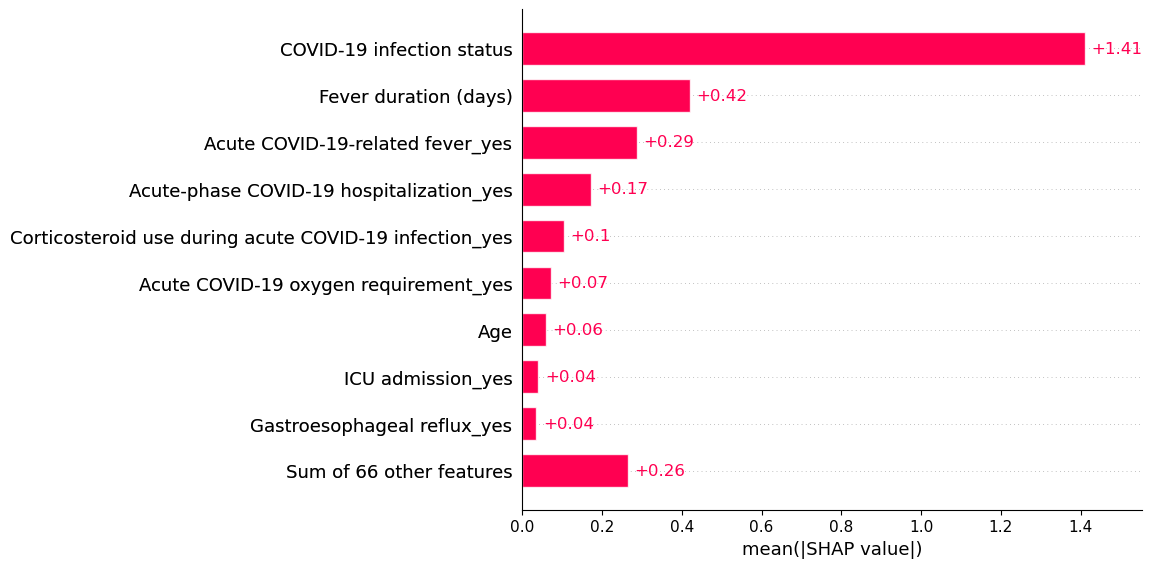

In [72]:
shap.plots.bar(shap_values)

### Binary Classification

In [76]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score

target2 = "Post covid severeness"

# Extract y labels
y_train_sev = y_train_clean[target2]
y_test_sev  = y_test[target2]

# Initialize Random Forest
rf_sev = RandomForestClassifier(
    n_estimators=400,
    max_depth=3,
    random_state=42
)

# Train model
rf_sev.fit(X_train_clean, y_train_sev)

# Predict
y_pred_sev = rf_sev.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test_sev, y_pred_sev)
precision = precision_score(y_test_sev, y_pred_sev)
recall = recall_score(y_test_sev, y_pred_sev)

print("=== RANDOM FOREST: Post COVID Severeness ===")
print(f"Accuracy:  {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall:    {recall*100:.2f}%")


=== RANDOM FOREST: Post COVID Severeness ===
Accuracy:  78.46%
Precision: 85.00%
Recall:    60.71%


In [77]:
import shap

# Fits the explainer
explainer = shap.Explainer(rf_sev.predict, X_test)
# Calculates the SHAP values - It takes some time
shap_values = explainer(X_test)

PermutationExplainer explainer: 66it [00:15,  1.76it/s]                        


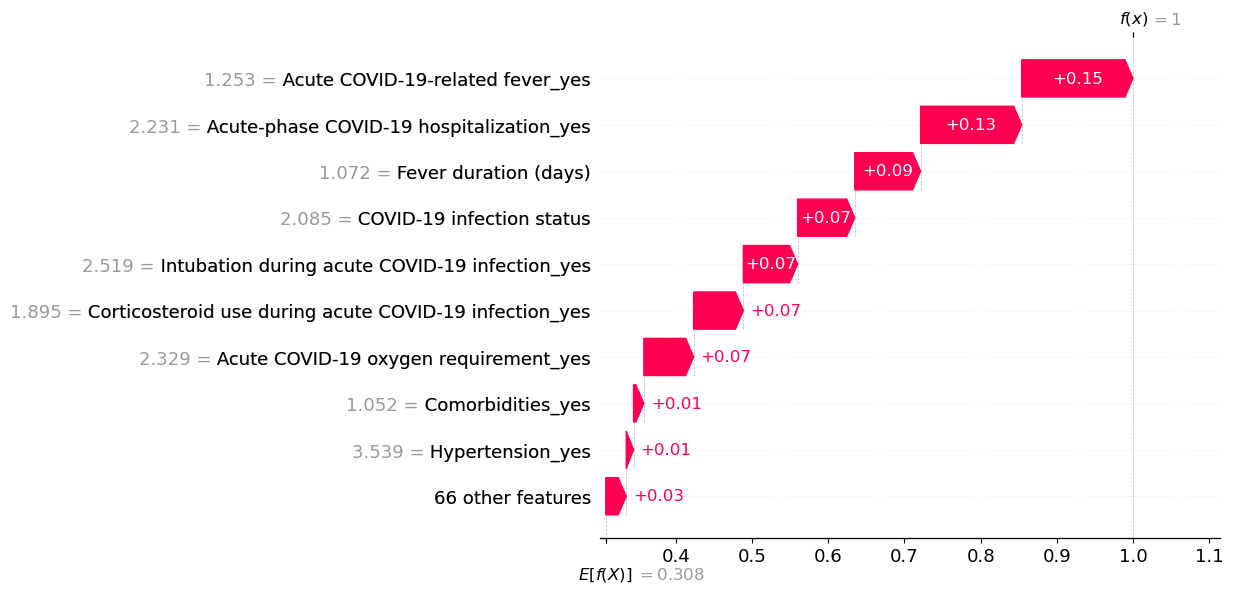

In [80]:
shap.waterfall_plot(shap_values[0])

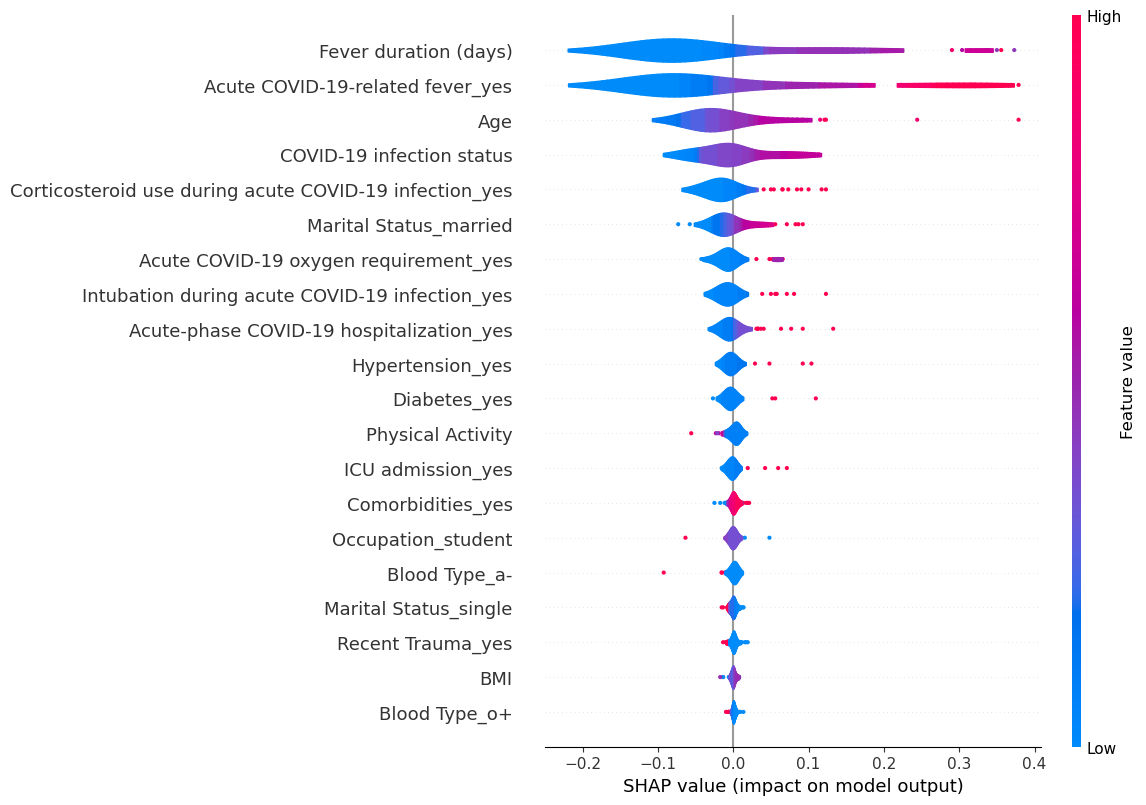

In [82]:
shap.violin_plot(shap_values, plot_type='violin')


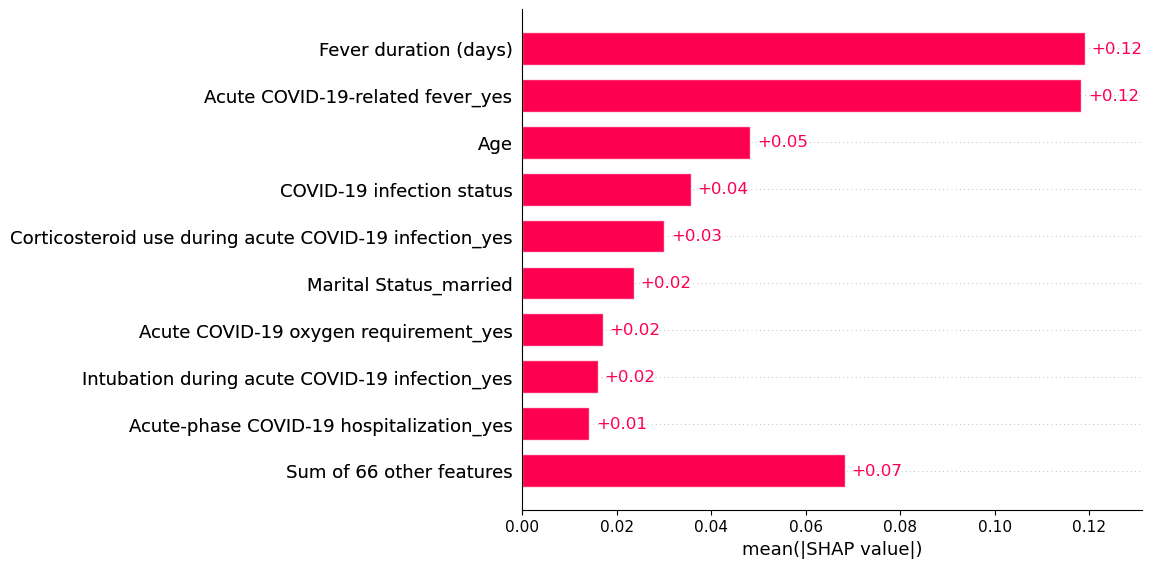

In [83]:
shap.plots.bar(shap_values)

### Multiclass Classification

### FSS Score

In [150]:
from sklearn.metrics import classification_report

target3 = "FSS score"

# Extract labels
y_train_fss = y_train_clean[target3]
y_test_fss  = y_test[target3]

# Initialize Random Forest
rf_fss = RandomForestClassifier(
    n_estimators=400,
    max_depth=3,
    random_state=42
)

# Train model
rf_fss.fit(X_train_clean, y_train_fss)

# Predict
y_pred_fss = rf_fss.predict(X_test)

print("\n=== RANDOM FOREST: FSS SCORE (MULTI-CLASS) ===")
print(classification_report(y_test_fss, y_pred_fss))
# Metrics
accuracy = accuracy_score(y_test_fss, y_pred_fss)
print(f"Accuracy:  {accuracy*100:.2f}%")




=== RANDOM FOREST: FSS SCORE (MULTI-CLASS) ===
              precision    recall  f1-score   support

           0       0.69      0.97      0.80        38
           1       0.00      0.00      0.00        10
           2       0.70      0.44      0.54        16
           3       0.00      0.00      0.00         1

    accuracy                           0.68        65
   macro avg       0.35      0.35      0.34        65
weighted avg       0.57      0.68      0.60        65

Accuracy:  67.69%


C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(65, 75, 4)


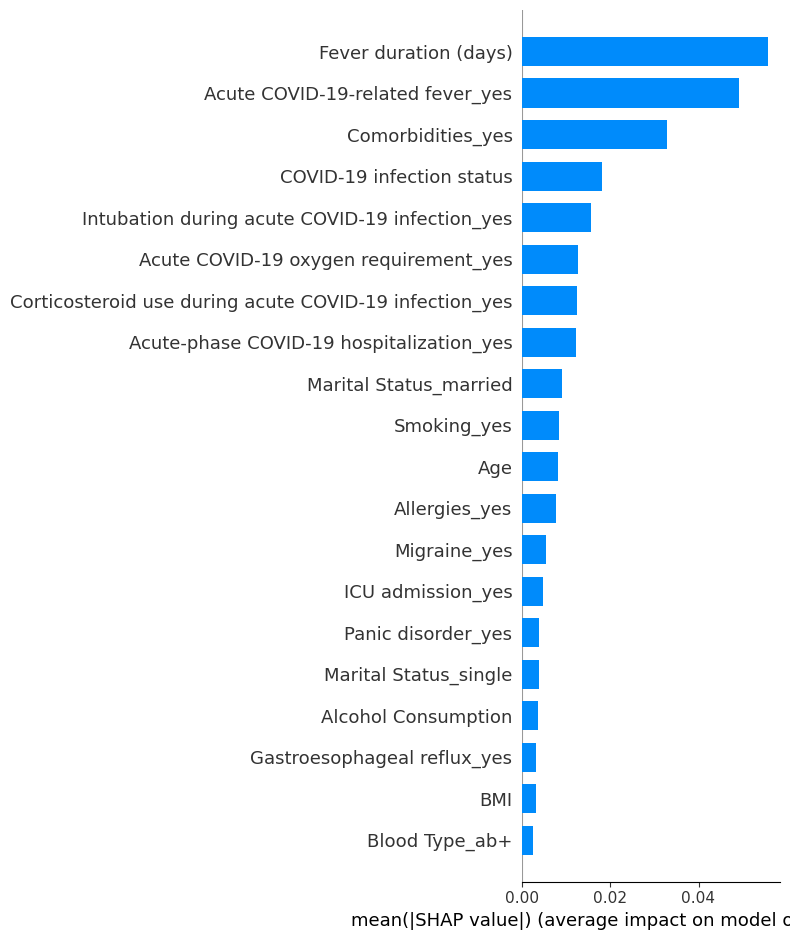

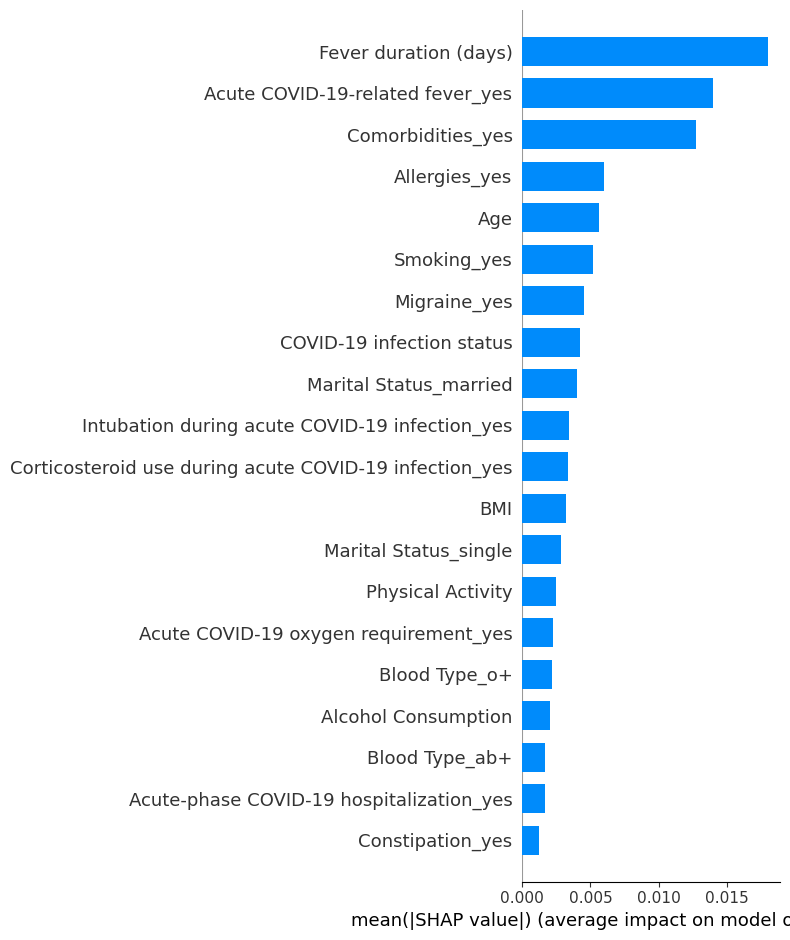

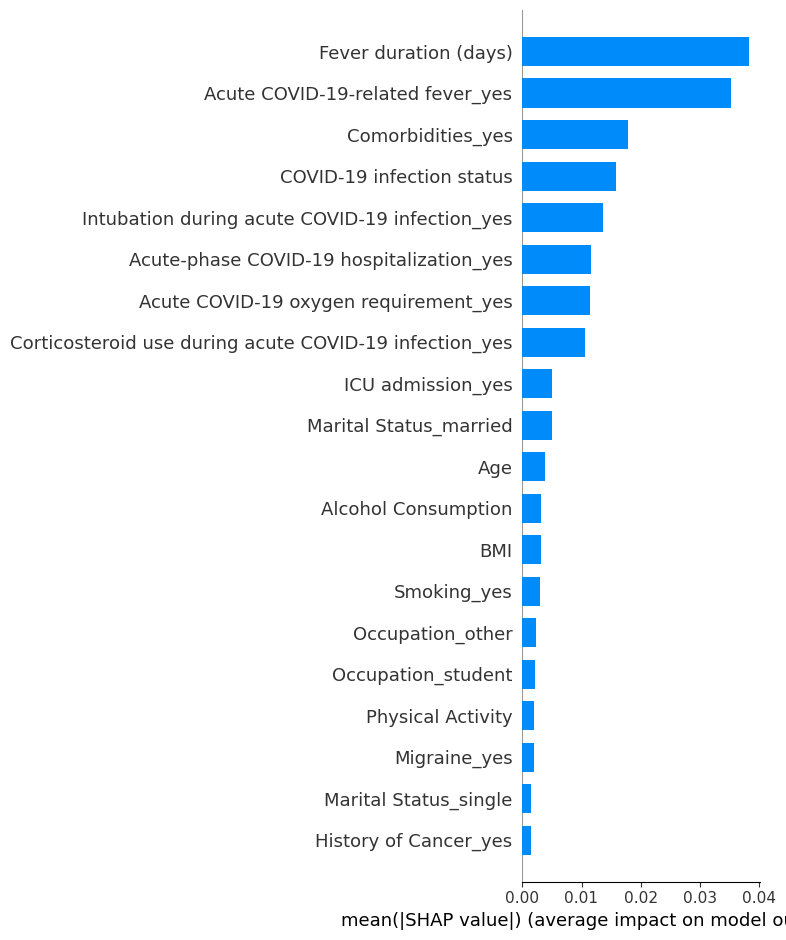

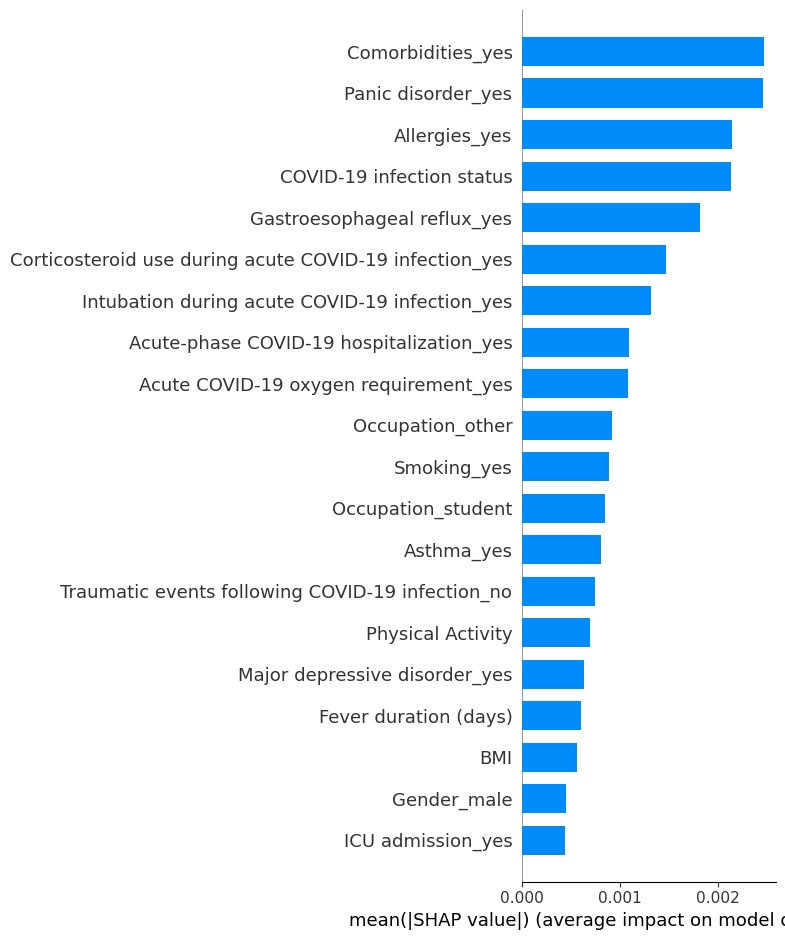

In [90]:
explainer = shap.TreeExplainer(rf_fss)
shap_values = explainer.shap_values(X_test,approximate=True)
print(shap_values.shape)
for i in range(4):
    shap.summary_plot(shap_values[:,:,i], X_test, plot_type="bar")



=== VIOLIN PLOT FOR CLASS 0 ===


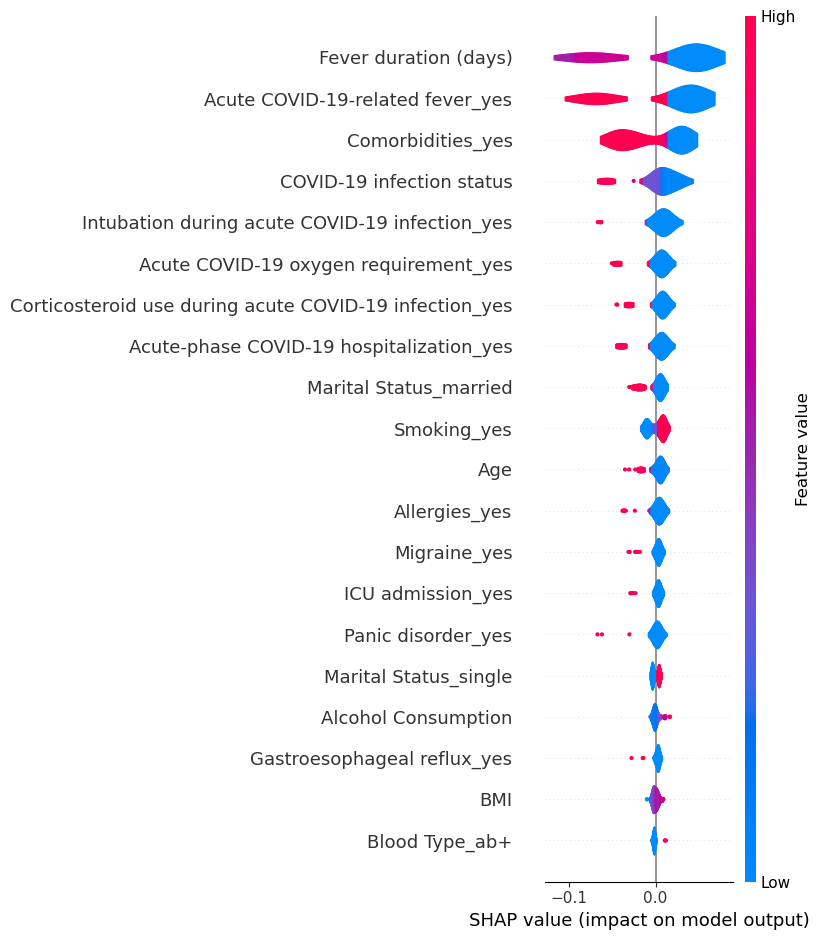


=== VIOLIN PLOT FOR CLASS 1 ===


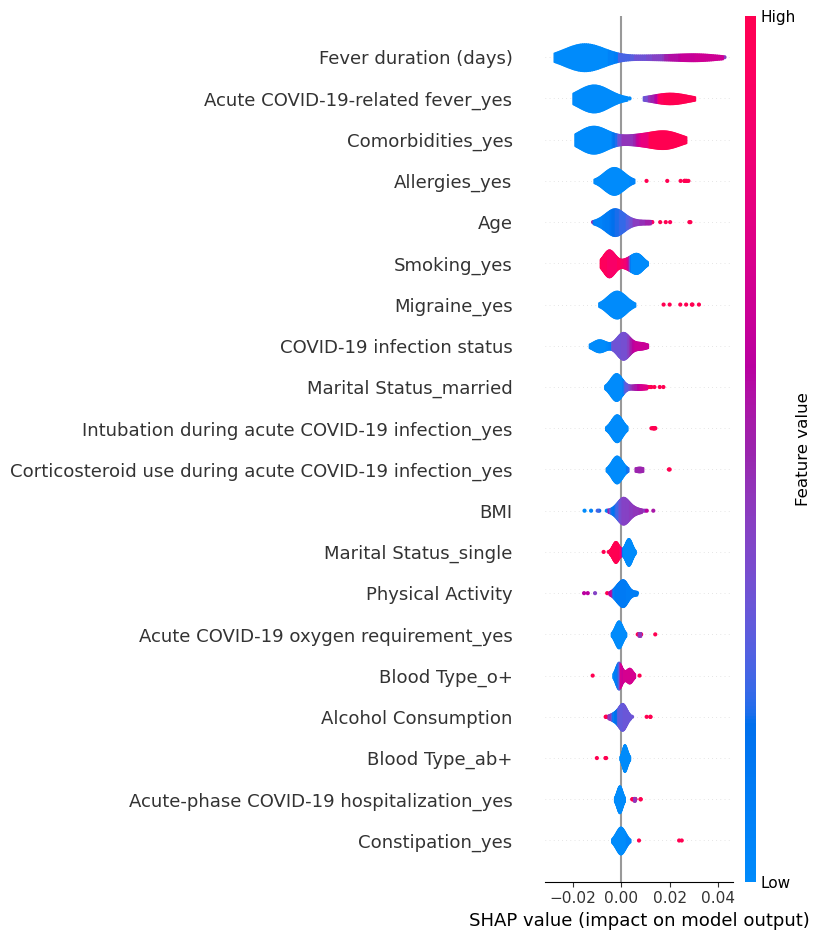


=== VIOLIN PLOT FOR CLASS 2 ===


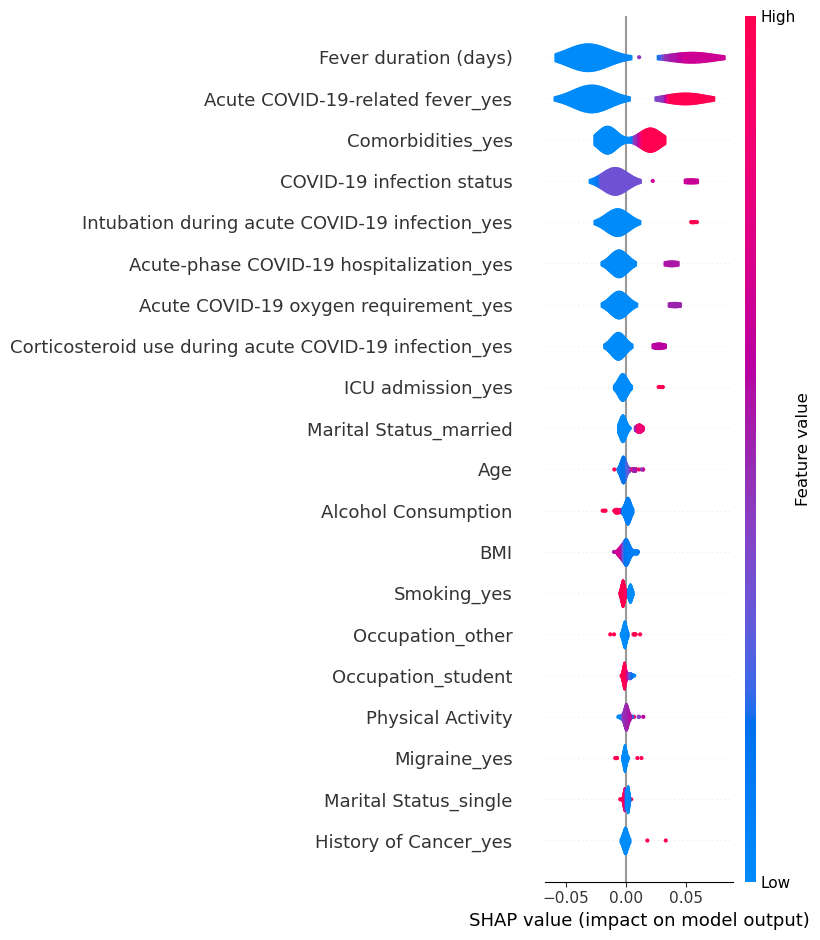


=== VIOLIN PLOT FOR CLASS 3 ===


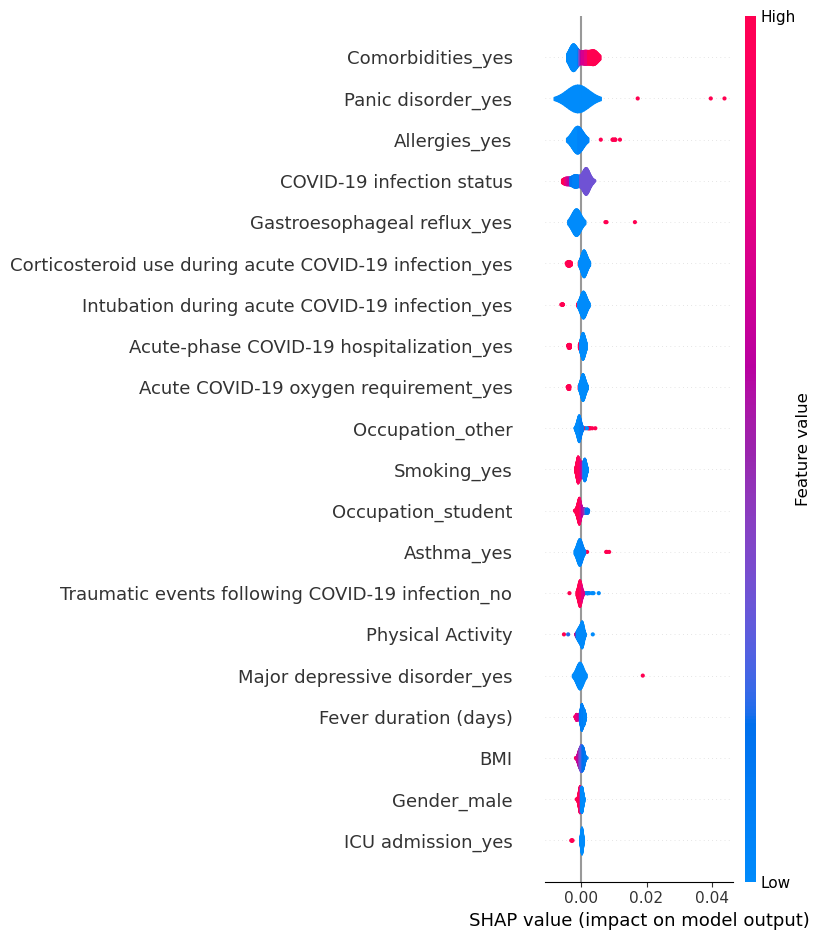

In [92]:
for cls in range(4):   # 0, 1, 2, 3
    print(f"\n=== VIOLIN PLOT FOR CLASS {cls} ===")
    shap.summary_plot(
        shap_values[:,:,cls],   # SHAP values for this class
        X_test,             # features
        plot_type="violin",
        show=True
    )

### GAD-7 Score

In [93]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

target4 = "GAD-7 score"

# Extract labels
y_train_gad = y_train_clean[target4]
y_test_gad  = y_test[target4]

print("Train class counts:\n", y_train_gad.value_counts())
print("\nTest class counts:\n", y_test_gad.value_counts())

# Initialize Random Forest (multi-class is automatic)
rf_gad = RandomForestClassifier(
    n_estimators=400,
    max_depth=4,
    random_state=42
)

# Train model
rf_gad.fit(X_train_clean, y_train_gad)

# Predict on test
y_pred_gad = rf_gad.predict(X_test)

# Overall accuracy
acc = accuracy_score(y_test_gad, y_pred_gad)
print(f"\n=== RANDOM FOREST: GAD-7 SCORE (MULTI-CLASS) ===")
print(f"Accuracy: {acc*100:.2f}%\n")

# Detailed metrics per class
print(classification_report(y_test_gad, y_pred_gad))


Train class counts:
 GAD-7 score
0    163
2     44
3     24
1     13
Name: count, dtype: int64

Test class counts:
 GAD-7 score
0    41
2    10
1     9
3     5
Name: count, dtype: int64

=== RANDOM FOREST: GAD-7 SCORE (MULTI-CLASS) ===
Accuracy: 67.69%

              precision    recall  f1-score   support

           0       0.70      0.95      0.80        41
           1       0.00      0.00      0.00         9
           2       0.56      0.50      0.53        10
           3       0.00      0.00      0.00         5

    accuracy                           0.68        65
   macro avg       0.31      0.36      0.33        65
weighted avg       0.52      0.68      0.59        65



C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(65, 75, 4)


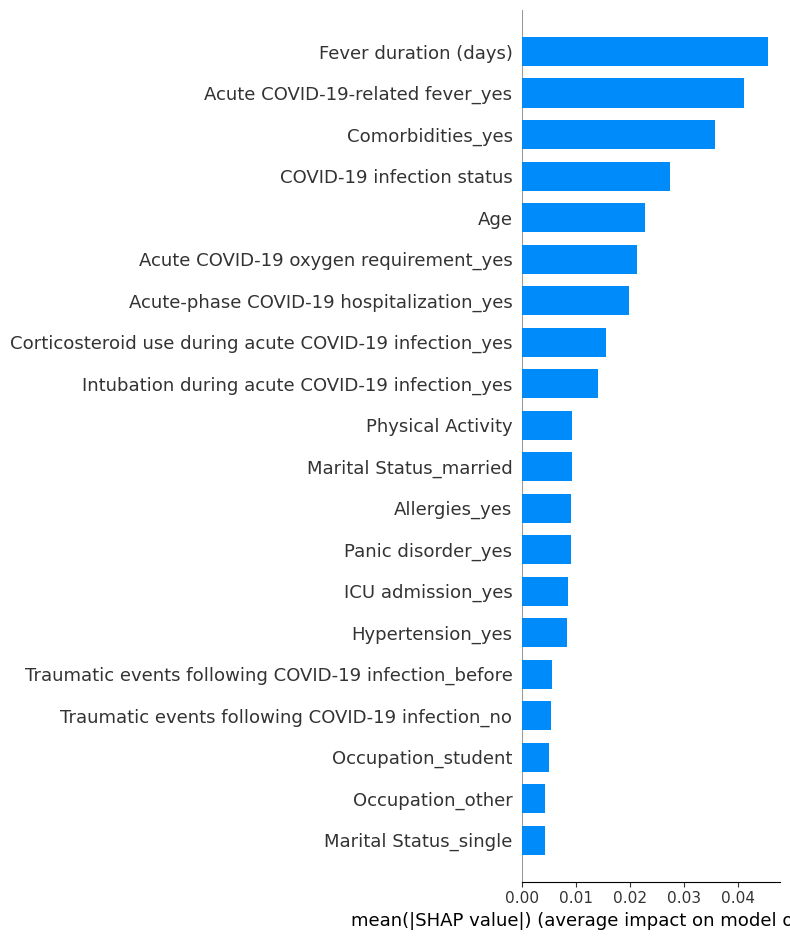

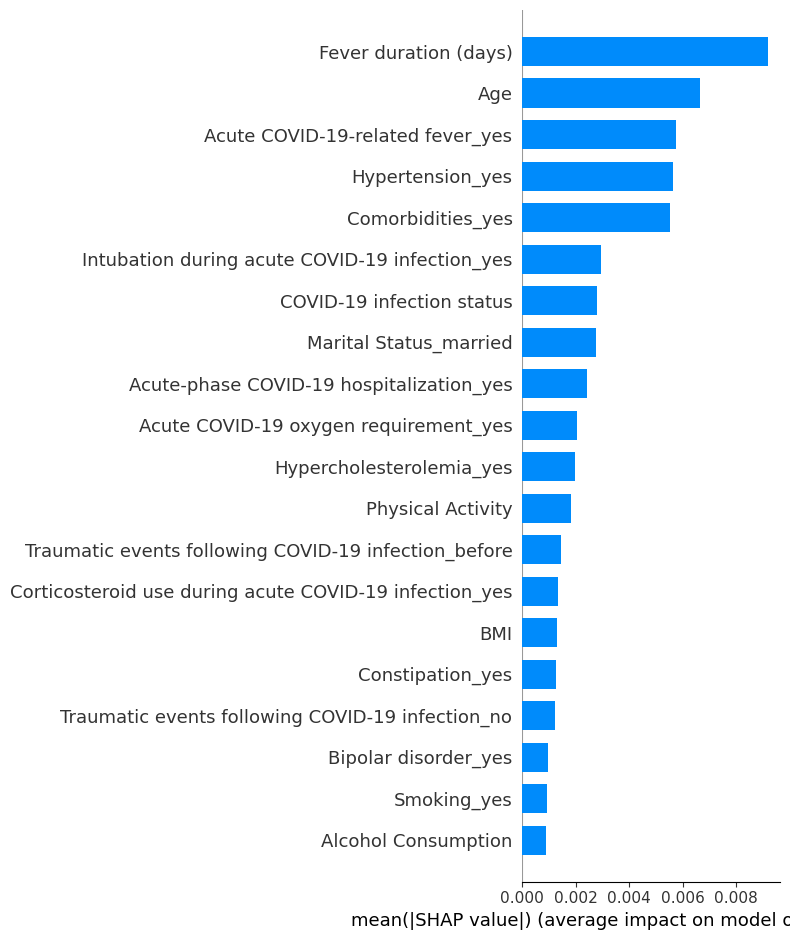

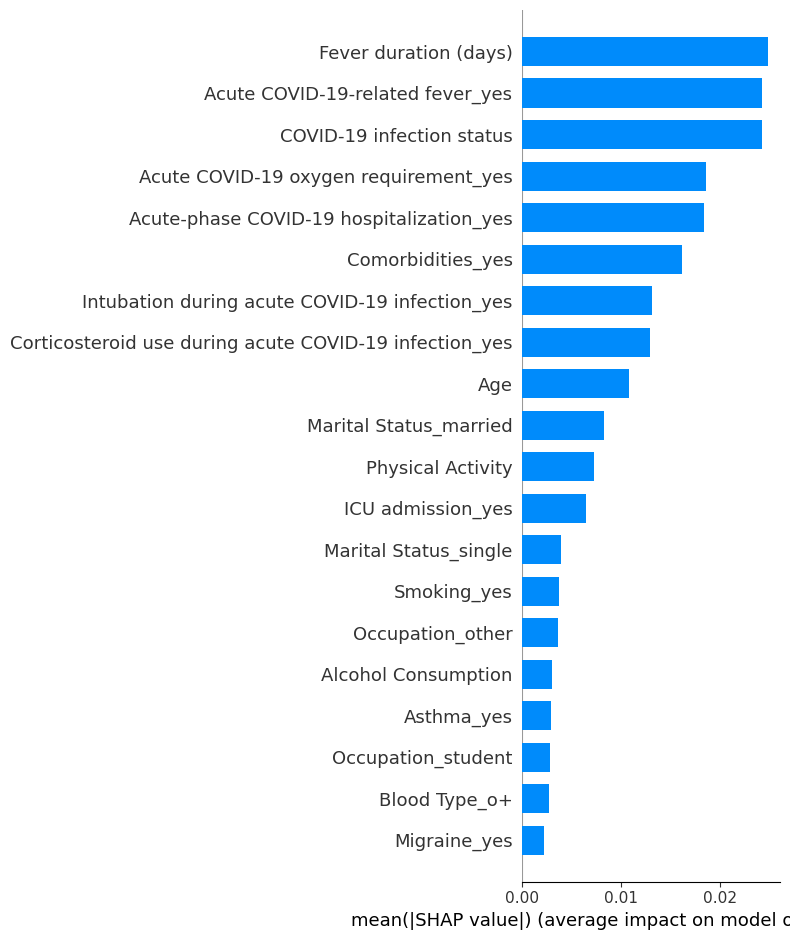

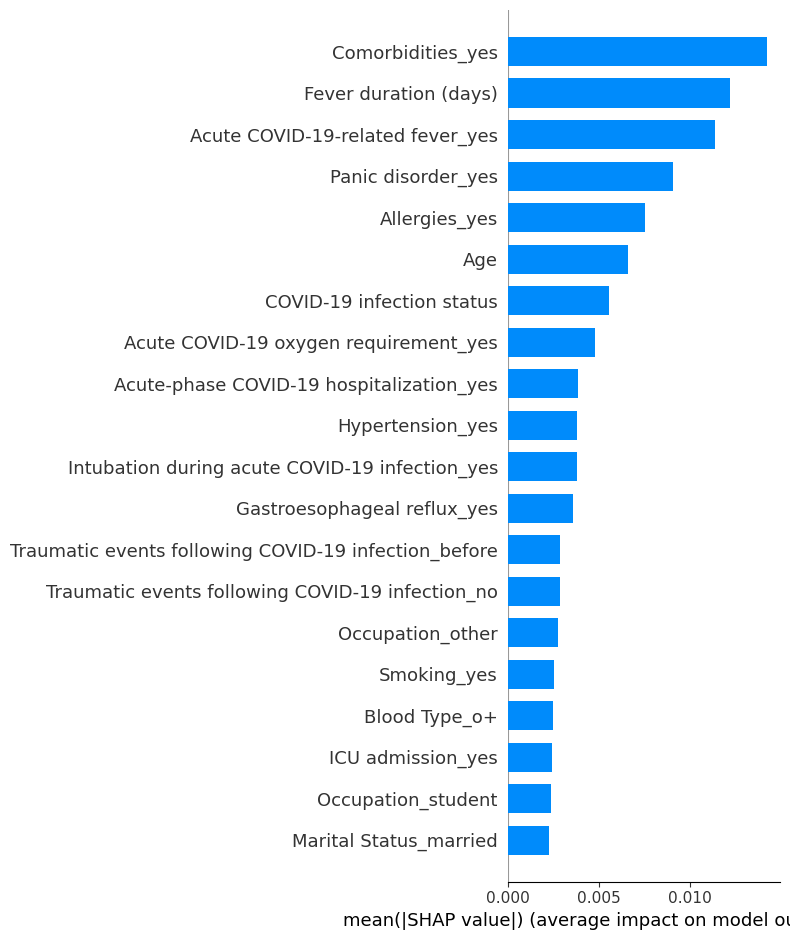

In [94]:
explainer = shap.TreeExplainer(rf_gad)
shap_values = explainer.shap_values(X_test,approximate=True)
print(shap_values.shape)
for i in range(4):
    shap.summary_plot(shap_values[:,:,i], X_test, plot_type="bar")



=== VIOLIN PLOT FOR CLASS 0 ===


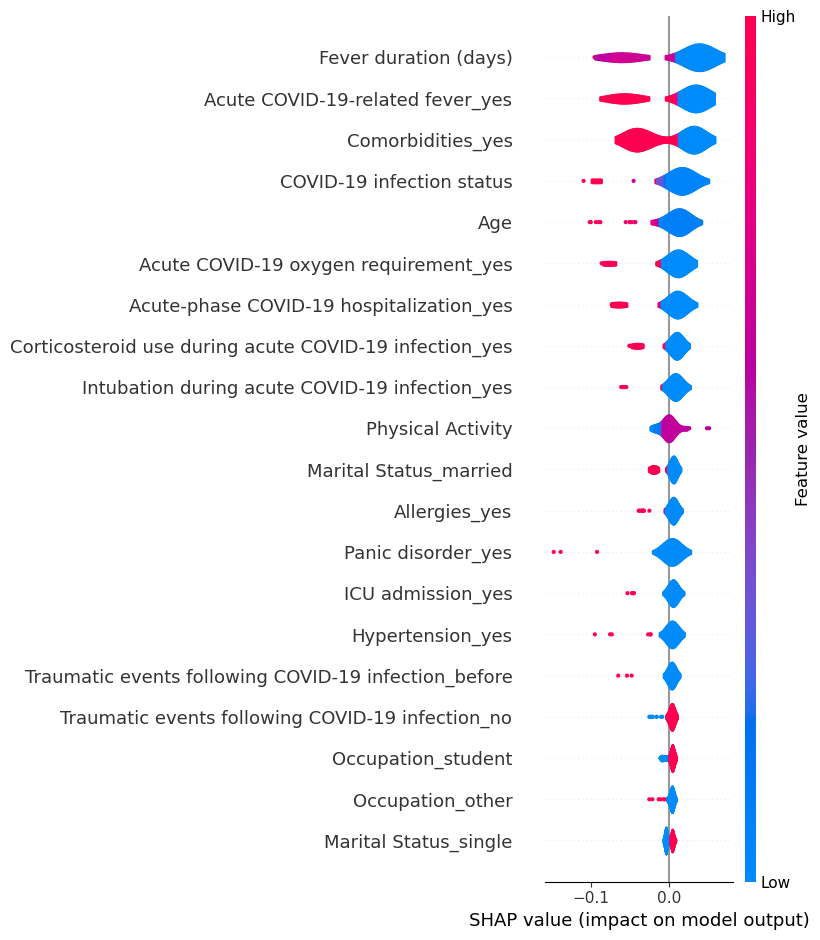


=== VIOLIN PLOT FOR CLASS 1 ===


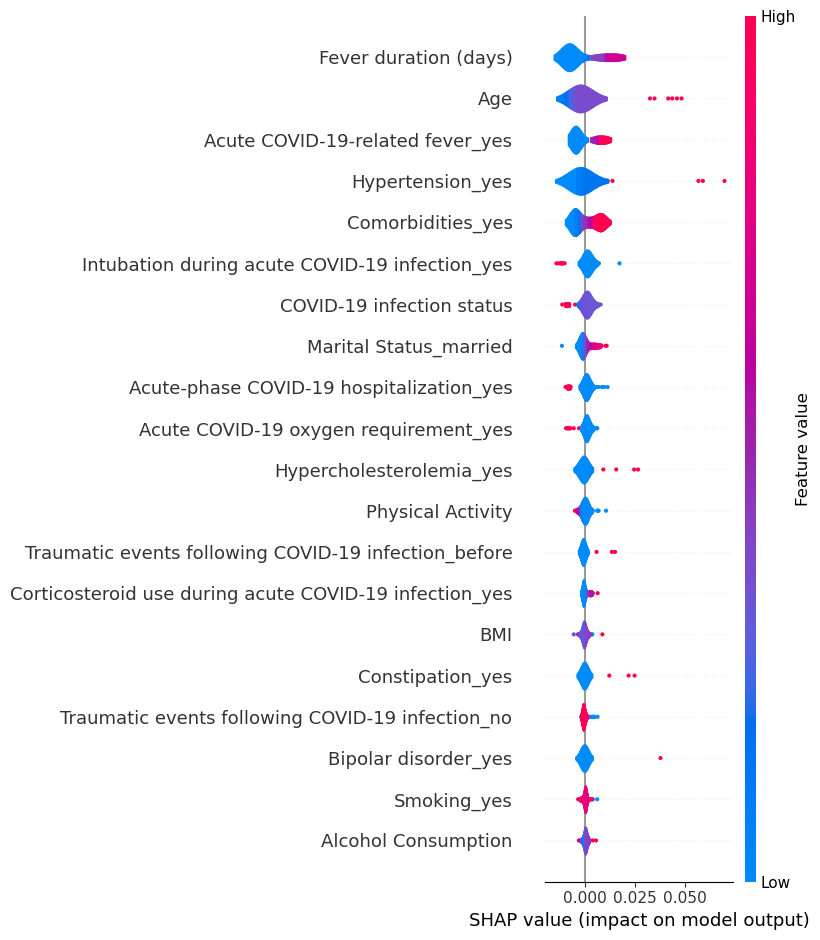


=== VIOLIN PLOT FOR CLASS 2 ===


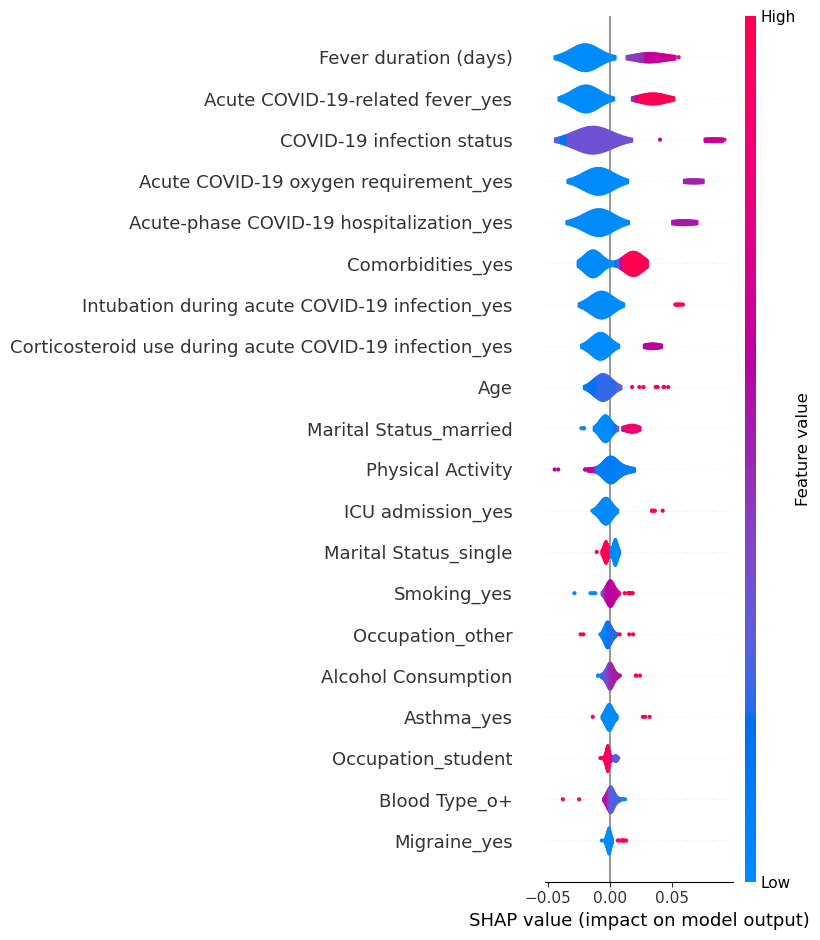


=== VIOLIN PLOT FOR CLASS 3 ===


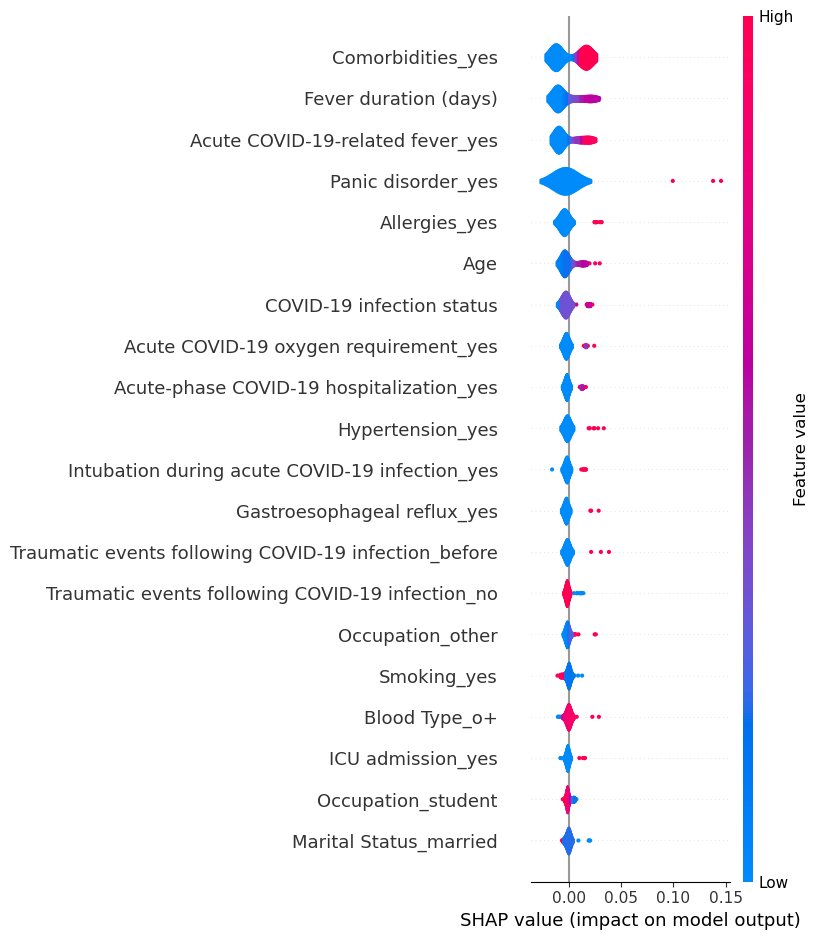

In [95]:
for cls in range(4):   # 0, 1, 2, 3
    print(f"\n=== VIOLIN PLOT FOR CLASS {cls} ===")
    shap.summary_plot(
        shap_values[:,:,cls],   # SHAP values for this class
        X_test,             # features
        plot_type="violin",
        show=True
    )